# 🌊 Water Potability Prediction Using Machine Learning

## Project Overview

Access to safe drinking water is essential for public health. This project uses Machine Learning techniques to predict whether water is potable (safe for drinking) based on various physicochemical parameters.

### Objectives

* Perform Exploratory Data Analysis (EDA)
* Handle missing values and class imbalance
* Train multiple machine learning models
* Compare model performance
* Analyze feature importance
* Predict water potability accurately

### Machine Learning Models Used

* Logistic Regression
* Random Forest Classifier
* XGBoost Classifier

### Dataset Features

The dataset contains various water quality parameters including:

* pH
* Hardness
* Solids
* Chloramines
* Sulfate
* Conductivity
* Organic Carbon
* Trihalomethanes
* Turbidity

### Target Variable

* 0 → Non-Potable Water
* 1 → Potable Water


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## Dataset Upload and Loading

The dataset is uploaded from the user's local machine and loaded into a Pandas DataFrame.

In [7]:
from google.colab import files
import io

print("Upload water_potability.csv")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("Dataset Loaded Successfully")
print("Shape:", df.shape)
df.head()

Upload water_potability.csv


Saving archive (1).csv to archive (1).csv
Dataset Loaded Successfully
Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890456,20791.31898,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.05786,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.54173,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.41744,8.059332,356.886136,363.266516,18.436525,100.341674,4.628771,0
4,9.092223,181.101509,17978.98634,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## Dataset Information

Understanding the structure, columns, and missing values present in the dataset.

In [8]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nColumns:")
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB
None

Missing Values:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Columns:
['ph', 'Hardne

## Data Cleaning

Missing values are replaced using mean imputation to ensure model training is not affected by incomplete records.

In [9]:
df.fillna(df.mean(), inplace=True)

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


## Target Variable Identification

Identify the potability column used for prediction.

In [11]:
target_column = None

possible_targets = [
    'Potability',
    'potability',
    'Target',
    'target',
    'Class',
    'class',
    'Quality',
    'quality'
]

for col in possible_targets:
    if col in df.columns:
        target_column = col
        break

if target_column is None:
    target_column = df.columns[-1]

print("Target Variable:", target_column)

Target Variable: Potability


## Exploratory Data Analysis (EDA)

Analyze distributions, class balance, and feature behavior.

In [12]:
print(df.describe())

print("\nTarget Distribution:")
print(df[target_column].value_counts())

print("\nTarget Ratio:")
print(df[target_column].value_counts(normalize=True))

                ph     Hardness        Solids  Chloramines      Sulfate  \
count  3276.000000  3276.000000   3276.000000  3276.000000  3276.000000   
mean      7.080795   196.369496  22014.092526     7.122277   333.775777   
std       1.469956    32.879761   8768.570828     1.583085    36.142612   
min       0.000000    47.432000    320.942611     0.352000   129.000000   
25%       6.277673   176.850538  15666.690300     6.127421   317.094638   
50%       7.080795   196.967627  20927.833605     7.130299   333.775777   
75%       7.870050   216.667456  27332.762125     8.114887   350.385756   
max      14.000000   323.124000  61227.196010    13.127000   481.030642   

       Conductivity  Organic_carbon  Trihalomethanes    Turbidity   Potability  
count   3276.000000     3276.000000      3276.000000  3276.000000  3276.000000  
mean     426.205111       14.284970        66.396293     3.966786     0.390110  
std       80.824064        3.308162        15.769881     0.780382     0.487849  


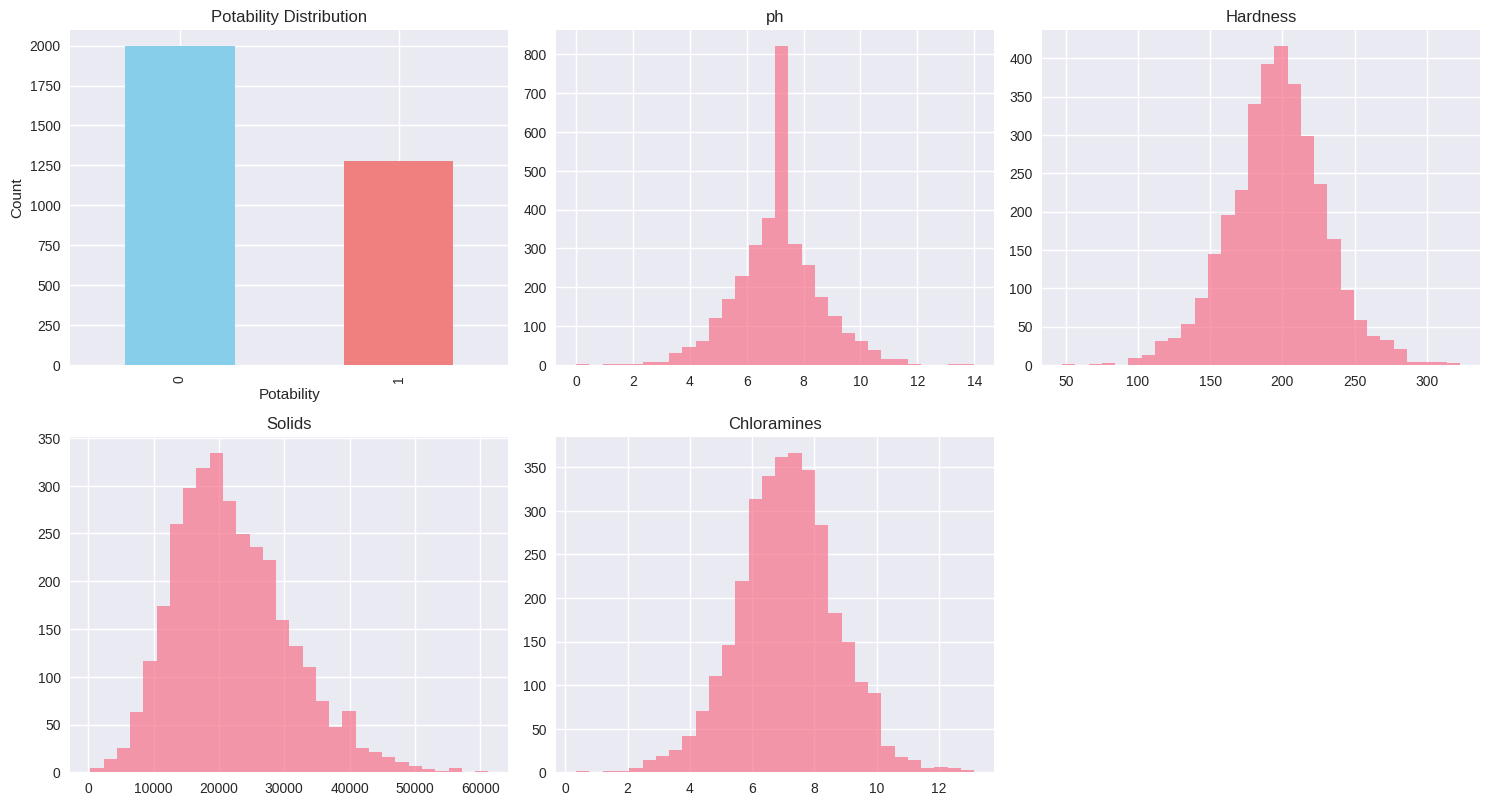

In [13]:
plt.figure(figsize=(15,12))

plt.subplot(3,3,1)
df[target_column].value_counts().plot(
    kind='bar',
    color=['skyblue','lightcoral']
)

plt.title("Potability Distribution")
plt.xlabel("Potability")
plt.ylabel("Count")

feature_columns = [c for c in df.columns if c != target_column]

for i in range(min(4,len(feature_columns))):
    plt.subplot(3,3,i+2)
    df[feature_columns[i]].hist(
        bins=30,
        alpha=0.7
    )
    plt.title(feature_columns[i])

plt.tight_layout()
plt.show()

## Correlation Analysis

Study relationships between variables using a correlation heatmap.

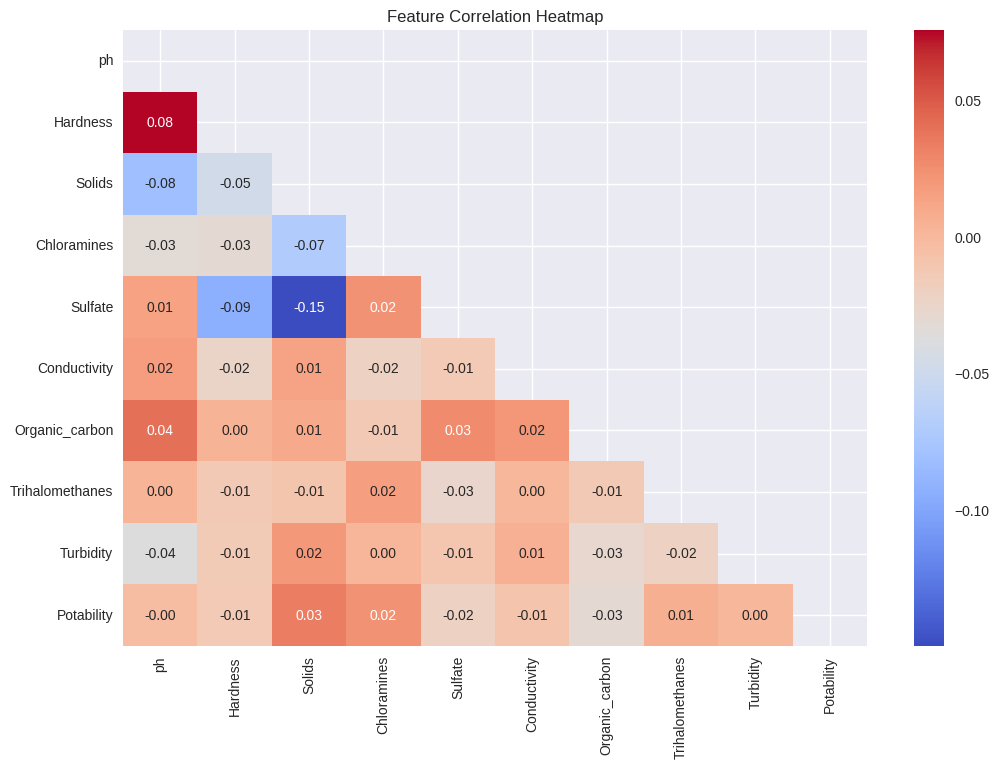

In [14]:
plt.figure(figsize=(12,8))

correlation_matrix = df.corr()

mask = np.triu(
    np.ones_like(
        correlation_matrix,
        dtype=bool
    )
)

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")
plt.show()

## Data Preprocessing

Prepare data for machine learning:
- Train/Test Split
- Standard Scaling
- SMOTE Oversampling

In [15]:
X = df.drop(target_column, axis=1)
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Training Shape:", X_train_balanced.shape)

Training Shape: (3196, 9)


## Model Training

Train Logistic Regression, Random Forest, and XGBoost models.

In [17]:
models = {
    "Logistic Regression":
        LogisticRegression(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric='logloss'
        )
}

In [18]:
results = {}

for name, model in models.items():

    model.fit(
        X_train_balanced,
        y_train_balanced
    )

    y_pred = model.predict(X_test_scaled)

    y_pred_proba = model.predict_proba(
        X_test_scaled
    )[:,1]

    results[name] = {
        'model': model,
        'accuracy': accuracy_score(y_test,y_pred),
        'precision': precision_score(y_test,y_pred),
        'recall': recall_score(y_test,y_pred),
        'f1': f1_score(y_test,y_pred),
        'roc_auc': roc_auc_score(y_test,y_pred_proba),
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }

## Model Performance Comparison

In [19]:
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1-Score': [results[m]['f1'] for m in results],
    'ROC-AUC': [results[m]['roc_auc'] for m in results]
})

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.525915,0.416413,0.535156,0.468376,0.545684
1,Random Forest,0.660061,0.581281,0.460938,0.514161,0.667100
2,XGBoost,0.608232,0.497976,0.480469,0.489066,0.633330


## ROC Curve Analysis

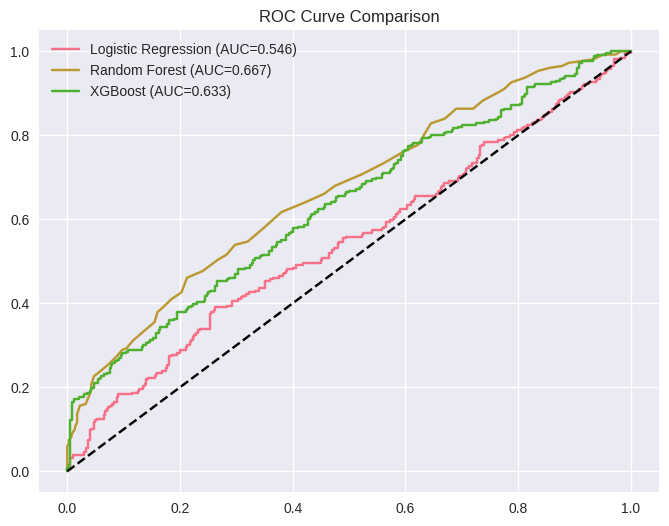

In [20]:
plt.figure(figsize=(8,6))

for name, result in results.items():
    fpr, tpr, _ = roc_curve(
        y_test,
        result['probabilities']
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={result['roc_auc']:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.legend()
plt.title("ROC Curve Comparison")
plt.show()

## 11. Feature Importance Analysis

In [21]:
rf_importance = results[
    'Random Forest'
]['model'].feature_importances_

xgb_importance = results[
    'XGBoost'
]['model'].feature_importances_

In [22]:
combined_importance = (
    rf_importance + xgb_importance
) / 2

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': combined_importance
}).sort_values(
    'Importance',
    ascending=False
)

feature_importance_df

,Feature,Importance
0,ph,0.135913
4,Sulfate,0.130773
3,Chloramines,0.120140
1,Hardness,0.115646
2,Solids,0.107960
5,Conductivity,0.099615
8,Turbidity,0.097485
7,Trihalomethanes,0.097009
6,Organic_carbon,0.095459


##  Best Model Evaluation

In [23]:
best_model_name = max(
    results,
    key=lambda x: results[x]['f1']
)

print(best_model_name)

print(
    classification_report(
        y_test,
        results[best_model_name]['predictions']
    )
)

Random Forest
              precision    recall  f1-score   support

           0       0.70      0.79      0.74       400
           1       0.58      0.46      0.51       256

    accuracy                           0.66       656
   macro avg       0.64      0.62      0.63       656
weighted avg       0.65      0.66      0.65       656



# Conclusion

The project successfully predicts water potability using Machine Learning models.

Key techniques used:

- Missing Value Imputation
- Standardization
- SMOTE Oversampling
- Logistic Regression
- Random Forest
- XGBoost

The best-performing model was selected using F1-Score and ROC-AUC metrics.

This workflow can support water quality monitoring and decision-making systems.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!find /content/drive -name "*.csv"